# Initialize the instrument

In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [4]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
sr400 = SR400.SR400('GPIB0::23::INSTR', timeout = 1000)

In [7]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [8]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


# Define the pulse

In [9]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],   # MOT
                     [["B", 10e-6, 5e-6, 15],    # 780 excitation 20dB attenuator connected
                      ["C", 10e-6, 5e-6, "TTL"]],    # 480 exc
                     ["D", 20e-6, 0, 8],        # DEI switch
                    ]
T = 1000e-6

cycle_number = 30
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

# stepper motor slope
freq_factor = 129 #kHz

notes = {"gate_width": gate_width, "gate_delay": gate_delay}

In [10]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num = cycle_number, 
                  dwell = 0, sourceA = "INPUT1", sourceB = "INPUT2", gate_A_mode = "FIXED",
                  gate_A_delay = gate_delay, gate_A_width = gate_width, gate_B_mode = "CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [12]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [13]:
bnc575.start_pulses()

# Search the resonance

In [108]:
weeder.position(header = "A", query = True)

'A4060'

In [111]:
weeder.move("A", position = 3800, progress = True)

start at 3700 --> 3800.0 --> 3800
Old position: 3700
New position: 3800


In [112]:
s = time.time()
weeder.advance(header = "A", num_step = 10)
e = time.time()
print(e-s)

start at 3800 --> 3810.0 --> 3810
Old position: 3800
New position: 3810
0.20484471321105957


# Stark map

## Scan parameters

In [216]:
center = 3760
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [233]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)

results = []
s = time.time()
for idx in x_list:
    print(f"now checking step: {idx}", end = "\r", flush=True)
    sr400.count_reset()
    result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A","+")
    time.sleep(0.1)
e = time.time()
print(e-s)

start at 3960 --> 3460.0 --> 3460
Old position: 3960
New position: 3460
start at 3460 --> 3560.0 --> 3560
Old position: 3460
New position: 3560
88.32313847541809: 399.0


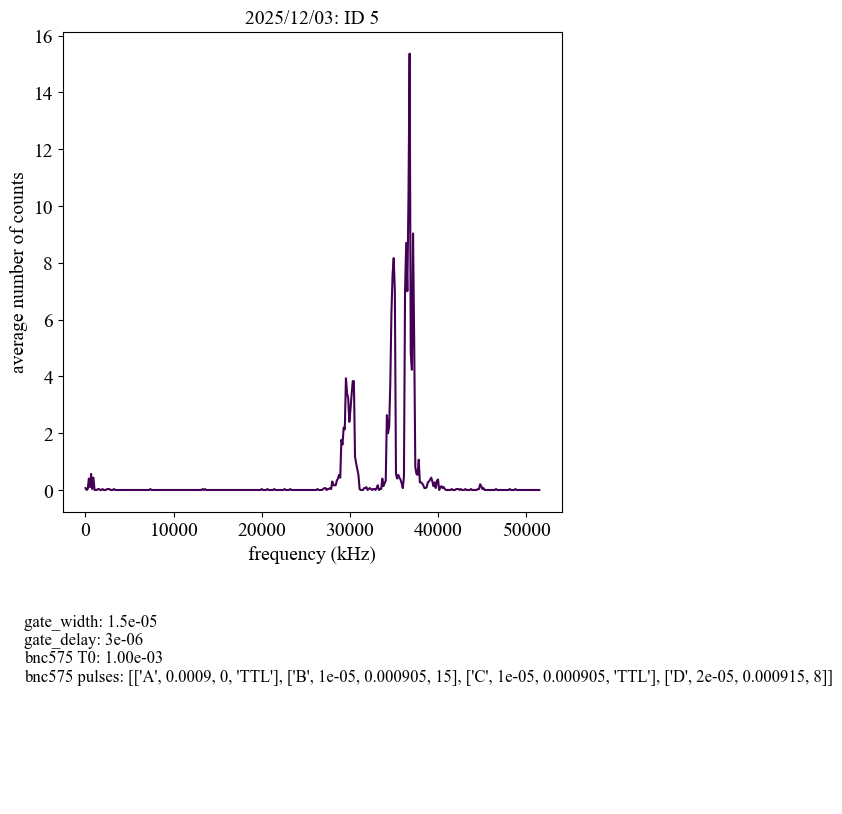

In [234]:
ps.Plot2D(x = x_list*stride*freq_factor, y = None, Z = results,
          xlabel = "frequency (kHz)", zlabel = "average number of counts", notes = notes)

### Lorentizian fit

In [183]:
from scipy.optimize import curve_fit

In [232]:
mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = -0.5, bipolar = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = 0.5, bipolar = True)

Channel 10 has been set to -0.5 V.
Channel 11 has been set to 0.5 V.


In [187]:
def three_lorentzian( x,
                     x0_1, a_1, gam_1,
                     x0_2, a_2, gam_2,
                     x0_3, a_3, gam_3):
    return a_1 * gam_1**2 / ( gam_1**2 + ( x - x0_1 )**2) + a_2 * gam_2**2 / ( gam_2**2 + ( x - x0_2 )**2) + a_3 * gam_3**2 / ( gam_3**2 + ( x - x0_3)**2)

In [201]:
def two_lorentzian( x,
                     x0_1, a_1, gam_1,
                     x0_2, a_2, gam_2,):
    return a_1 * gam_1**2 / ( gam_1**2 + ( x - x0_1 )**2) + a_2 * gam_2**2 / ( gam_2**2 + ( x - x0_2 )**2)

In [219]:
def lorentzian( x, x0_1, a_1, gam_1):
    return a_1 * gam_1**2 / ( gam_1**2 + ( x - x0_1 )**2) 

In [244]:
# p0 = np.array([33000, 4, 100, 33000, 4, 100, 36000, 7, 150]) 
p0 = np.array([33000, 6, 100, 36000, 16, 150]) 
# p0 = np.array([0, 1, 10, 30000, 7, 100])
popt, pcov = curve_fit(two_lorentzian, x_list[100:]*stride*freq_factor, results[100:], maxfev = 2000000)

[ 1.84330551e+04 -1.05079456e+00 -5.13525864e+03 -2.46949804e+07
  1.34423776e+05  6.27375547e+04]


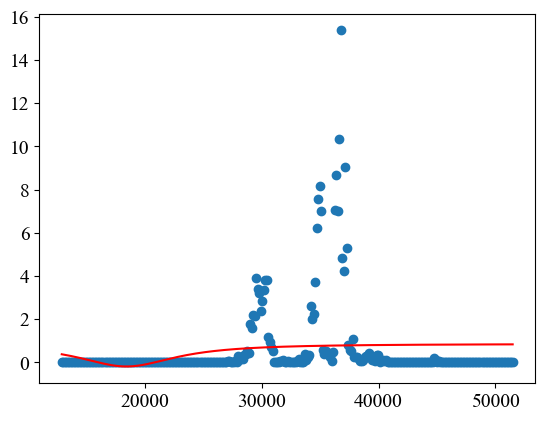

In [243]:
plt.scatter(x_list[100:]*stride*freq_factor, results[100:], label='Data')
plt.plot(x_list[100:]*stride*freq_factor, two_lorentzian(x_list[100:]*stride*freq_factor, *popt), 'r-', label='Fitted curve')
print(popt)

## 2D

### frequency inside voltage

In [ ]:
center = 3700
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [ ]:
start_position = center - half_width

v_list = np.linspace(-1,1,11)
stark_map = []

s = time.time()
for v in v_list:
    mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
    mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
    
    # everytime go further and go back to release the band tension and gear margin
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    results = []
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.1)
    stark_map.append(results)

e = time.time()
print(e-s)

In [ ]:
ps.Plot3D(x = v_list, y =x_list*stride*freq_factor , Z = stark_map,
          xlabel = "x voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

### voltage inside frequency

In [20]:
center = 3800
stride = 1
half_width = 200


# scan list gneration
s_list = np.arange(2* half_width/stride)

# the 0 point

vx0 = 0
vy0 = 0
vz0 = 0

vx_list = np.linspace(-1,1,11) + vx0
vy_list = np.linspace(-1,1,11) + vy0
vz_list = np.linspace(-1,2,11) + vz0

In [21]:
start_position = center - half_width


stark_map_x = []
stark_map_y = []
stark_map_z = []


weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)

s = time.time()
for x in x_list:
    for i in range(stride):
            weeder.step("A","+")
    print(f"now checking step: {x}", end = "\r", flush=True)
    time.sleep(0.1)
    
    results_x = []
    # results_y = []
    # results_z = []
    for vx in vx_list:
        # scan x
        mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = vx, bipolar = True, display=False)
        mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -vx, bipolar = True, display=False)
        time.sleep(0.01)
        sr400.count_reset()
        result_x = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results_x.append(result_x)
        
    stark_map_x.append(results_x)

    # for vy in vy_list:
    #     # scan y
    #     mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vy, bipolar = True, display=False)
    #     mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vy, bipolar = True, display=False)
    #     time.sleep(0.01)
    #     sr400.count_reset()
    #     result_y = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    #     results_y.append(result_y)
        
    # mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vy0, bipolar = True, display=False)
    # mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vy0, bipolar = True, display=False)
    # time.sleep(0.01)
    # stark_map_y.append(results_y)

    # for vz in vz_list:
    #     # scan z
    #     mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display=False)
    #     mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vz, bipolar = True, display=False)
    #     time.sleep(0.01)
    #     sr400.count_reset()
    #     result_z = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    #     results_z.append(result_z)
        
    # mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display=False)
    # mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vz0, bipolar = True, display=False)
    # time.sleep(0.01)
    # stark_map_z.append(results_z)

e = time.time()
print(e-s)

start at 3960 --> 3400.0 --> 3400
Old position: 3960
New position: 3400
start at 3400 --> 3500.0 --> 3500
Old position: 3400
New position: 3500
565.5085668563843: 399.0


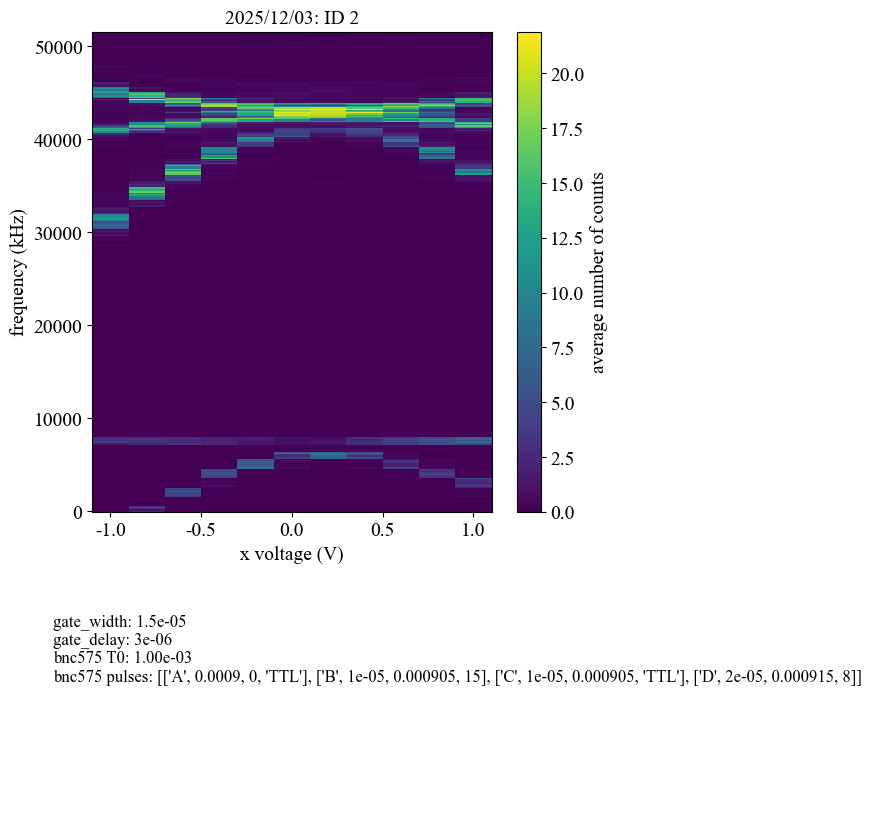

In [22]:
ps.Plot3D(x = vx_list, y =x_list*stride*freq_factor , Z = np.array(stark_map_x).T,
          xlabel = "x voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

### get the curve

In [23]:
from scipy.signal import find_peaks

In [ ]:
print(len(stark_map))

In [ ]:
print(stark_map)

In [37]:
peaks_x = []
peaks_y = []
for i in range(len(stark_map)):
    freq_scan = stark_map[i]
    peaks,_ = find_peaks(freq_scan,height = 10, distance= 9)
    # print(peaks)
    for p in peaks:
        peaks_x.append(vx_list[i])
        peaks_y.append((x_list*stride*freq_factor)[p])


    

NameError: name 'stark_map' is not defined

In [ ]:
plt.pcolormesh(vx_list,x_list*stride*freq_factor,np.array(stark_map).T)
plt.scatter(peaks_x,peaks_y, c = "r")

In [49]:
peaks_x = []
peaks_y = []
peaks_list = []
for i in range(len(stark_map_x[0])):
    freq_scan = np.array(stark_map_x)[:,i]
    peaks,_ = find_peaks(freq_scan,height = 10, distance= 9)
    print(peaks)
    if len(peaks) == 3:
        for p in peaks:
            peaks_x.append(vx_list[i])
            peaks_y.append((x_list*stride*freq_factor)[p])
        peaks_list.append(peaks)
peaks_list = np.array(peaks_list)
peaks_x = np.reshape(peaks_x,(-1,3)).T
peaks_y = np.reshape(peaks_y,(-1,3)).T

[244 317 350]
[266 321 343]
[282 324 344]
[294 327 338]
[311 327 336]
[325 335]
[325 335]
[332]
[325 337]
[303 325 338]
[281 323 342]


In [51]:
print(peaks_x)
print(peaks_y)

[[-1.  -0.8 -0.6 -0.4 -0.2  0.8  1. ]
 [-1.  -0.8 -0.6 -0.4 -0.2  0.8  1. ]
 [-1.  -0.8 -0.6 -0.4 -0.2  0.8  1. ]]
[[31476. 34314. 36378. 37926. 40119. 39087. 36249.]
 [40893. 41409. 41796. 42183. 42183. 41925. 41667.]
 [45150. 44247. 44376. 43602. 43344. 43602. 44118.]]


0.18611226728776697


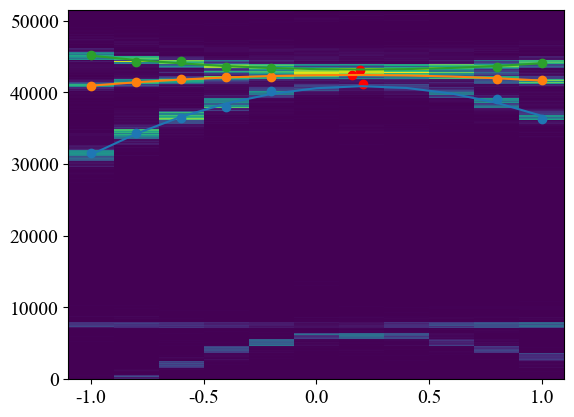

In [62]:
plt.pcolormesh(vx_list,x_list*stride*freq_factor,stark_map_x)
ssum = 0 
for i in range(3):
    a, b, c = np.polyfit(peaks_x[i], peaks_y[i], 2)
    plt.scatter(peaks_x[i],peaks_y[i])
    plt.plot(vx_list,a * vx_list**2 + b * vx_list +c)
    plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
    ssum += -b/(2*a)
print(ssum/3)

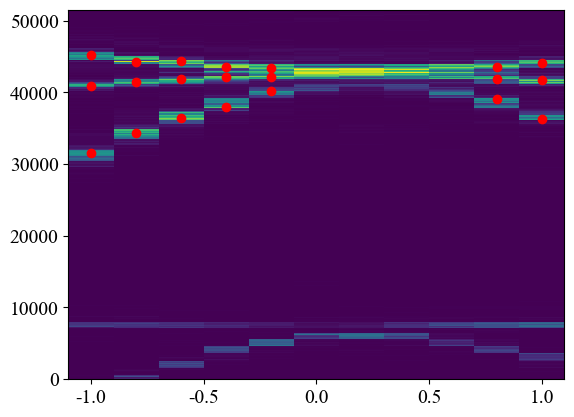

In [48]:
plt.pcolormesh(vx_list,x_list*stride*freq_factor,stark_map_x)
plt.scatter(peaks_x,peaks_y, c = "r")

### Compensation field

In [156]:
center = 3800
stride = 4
half_width = 200


# scan list gneration
s_list = np.arange(2* half_width/stride)

# the 0 point

v = np.array([0.,0.,0.])

vx_list = np.linspace(-1,2,11)
vy_list = np.linspace(-1,1,11)
vz_list = np.linspace(-1,2,11)

v_list = np.vstack((vx_list,vy_list,vz_list))
print(v_list)

electrode_pair = [[10,11],[6,7],[0,1]]

[[-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]
 [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
 [-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]]


In [139]:
print(v_list)

[[-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]
 [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
 [-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]]


In [140]:
start_position = center - half_width

stark_map = []

v_list = v_list + v.reshape(-1,1)

i = 0
print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)
for s in s_list:
    for j in range(stride):
            weeder.step("A","+")
    print(f"now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in v_list[i]:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
        else:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display=False)
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display=False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A",length = cycle_number))
        results.append(result)
        
    stark_map.append(results)



Now checking axis 0
start at 4000 --> 3500.0 --> 3500
Old position: 4000
New position: 3500
start at 3500 --> 3600.0 --> 3600
Old position: 3500
New position: 3600


[25 54 65]
[36 56 64]
[44 57 62]
[50 60]
[55 60]
[58]
[58]
[52 60]
[47 57]
[40 56 63]
[29 55 65]


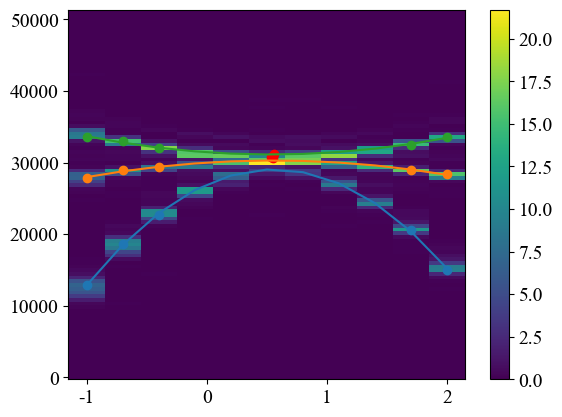

[0.5489949 0.        0.       ]
[0.5489949 0.        0.       ]


In [158]:
peaks_x = []
peaks_y = []
for k in range(len(stark_map[0])):
    freq_scan = np.array(stark_map)[:,k]
    peaks,_ = find_peaks(freq_scan, height = 1, distance = 5)
    print(peaks)
    if len(peaks) == 3:
        for p in peaks:
            peaks_x.append(v_list[i][k])
            peaks_y.append((s_list*stride*freq_factor)[p])
peaks_x = np.reshape(peaks_x,(-1,3)).T
peaks_y = np.reshape(peaks_y,(-1,3)).T
plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
plt.colorbar()
ssum = 0 
for l in range(3):
    a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
    plt.scatter(peaks_x[l],peaks_y[l])
    plt.plot(v_list[i],a * v_list[i]**2 + b * v_list[i] +c)
    plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
    ssum += -b/(2*a)

plt.show()

print(v)
v[0] =ssum/3
print(v)

In [159]:
a = np.array([1,2,3])
a[0] = 0.5
a[0]

0

In [ ]:
if electrode_pair[i][0] == 0:
    mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
else:
    mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v[i], bipolar = True, display=False)
mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v[i], bipolar = True, display=False)



Now checking axis 0
start at 3604 --> 3500.0 --> 3500
Old position: 3604
New position: 3500
start at 3500 --> 3600.0 --> 3600
Old position: 3500
New position: 3600


TypeError: expected non-empty vector for x

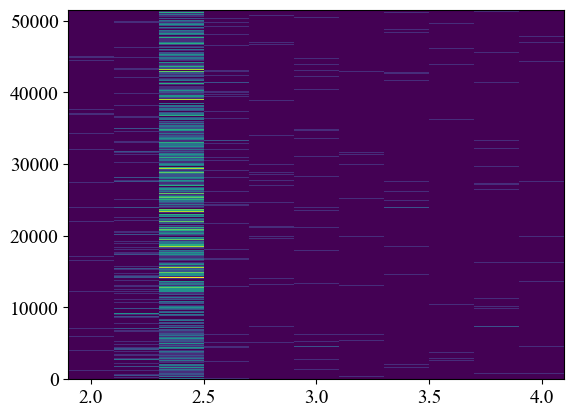

In [81]:
start_position = center - half_width

stark_map = []

v_list = v_list + v.reshape(-1,1)

for i in range(3):
    print('Now checking axis {}'.format(i))
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    for s in s_list:
        for j in range(stride):
                weeder.step("A","+")
        print(f"now checking step: {s}", end = "\r", flush = True)
        
        results = []
        for v_s in v_list[i]:
            # scan voltage
            if electrode_pair[i][0] == 0:
                mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
            else:
                mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display=False)
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display=False)
            time.sleep(0.01)
            sr400.count_reset()
            result = np.mean(sr400.read_entire_counts(counter = "A",length = cycle_number))
            results.append(result)
            
        stark_map.append(results)
    
    peaks_x = []
    peaks_y = []
    for k in range(len(stark_map[0])):
        freq_scan = np.array(stark_map)[:,k]
        peaks,_ = find_peaks(freq_scan, height = 10, distance = 9)
        # print(peaks)
        if len(peaks) == 3:
            for p in peaks:
                peaks_x.append(v_list[i][k])
                peaks_y.append((s_list*stride*freq_factor)[p])
    peaks_x = np.reshape(peaks_x,(-1,3)).T
    peaks_y = np.reshape(peaks_y,(-1,3)).T

    plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
    ssum = 0 
    for l in range(3):
        a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
        plt.scatter(peaks_x[l],peaks_y[l])
        plt.plot(v_list[i],a * v_list[i]**2 + b * v_list[i] +c)
        plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
        ssum += -b/(2*a)
    v[i] = ssum/3
    plt.show()
    
    if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
    else:
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v[i], bipolar = True, display=False)
    mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v[i], bipolar = True, display=False)

print(v)

In [ ]:
ps.Plot3D(x = vx_list, y =x_list*stride*freq_factor , Z = np.array(stark_map_x).T,
          xlabel = "x voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)
ps.Plot3D(x = vy_list, y =x_list*stride*freq_factor , Z = np.array(stark_map_y).T,
          xlabel = "y voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)
ps.Plot3D(x = vz_list, y =x_list*stride*freq_factor , Z = np.array(stark_map_z).T,
          xlabel = "z voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

# Compensation test

In [173]:
center = 3800
stride = 4
half_width = 200


# scan list gneration
s_list = np.arange(2* half_width/stride)

# the 0 point

v = np.array([0.44119122, 0.80112212, 0.73481402])

vx_list = np.linspace(-1,2,11)
vy_list = np.linspace(-1,1,11)
vz_list = np.linspace(-1,2,11)

v_list = np.vstack((vx_list,vy_list,vz_list))
# print(v_list)

electrode_pair = [[10,11],[6,7],[0,1]]

[[-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]
 [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
 [-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]]


In [175]:
start_position = center - half_width

# stark_map = []

v_list = v_list + v.reshape(-1,1)

for i in range(3):
    stark_map = []
    print('Now checking axis {}'.format(i))
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    for s in s_list:
        for j in range(stride):
                weeder.step("A","+")
        print(f"now checking step: {s}", end = "\r", flush = True)
        
        results = []
        for v_s in v_list[i]:
            # scan voltage
            if electrode_pair[i][0] == 0:
                mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
            else:
                mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display=False)
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display=False)
            time.sleep(0.01)
            sr400.count_reset()
            result = np.mean(sr400.read_entire_counts(counter = "A",length = cycle_number))
            results.append(result)
            
        stark_map.append(results)

    peaks_x = []
    peaks_y = []
    for k in range(len(stark_map[0])):
        freq_scan = np.array(stark_map)[:,k]
        peaks,_ = find_peaks(freq_scan, height = 1, distance = 5)
        print(peaks)
        if len(peaks) == 3:
            for p in peaks:
                peaks_x.append(v_list[i][k])
                peaks_y.append((s_list*stride*freq_factor)[p])
    peaks_x = np.reshape(peaks_x,(-1,3)).T
    peaks_y = np.reshape(peaks_y,(-1,3)).T
    plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
    plt.colorbar()
    ssum = 0 
    for l in range(3):
        a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
        plt.scatter(peaks_x[l],peaks_y[l])
        plt.plot(v_list[i],a * v_list[i]**2 + b * v_list[i] +c)
        plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
        ssum += -b/(2*a)
    
    plt.show()

    v[i] = ssum/3

    if electrode_pair[i][0] == 0:
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=True)
    else:
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v[i], bipolar = True, display=True)
    mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v[i], bipolar = True, display=True)

Now checking axis 0
start at 3515 --> 3500.0 --> 3500
Old position: 3515
New position: 3500
start at 3500 --> 3600.0 --> 3600
Old position: 3500
New position: 3600


KeyboardInterrupt: 

In [171]:
print(v)

[0.44119122 0.80112212 0.73481402]


# Stability test

In [ ]:
center = 3260 # changed from 3300
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)
#print(x_list)

In [ ]:
start_position = center - half_width
repeat_num = 30
resultss = []
for i in range(repeat_num):
    print("Now performing scan {}".format(i))
    results = []
    weeder.move(header = "A", position = start_position - 100)
    weeder.move(header = "A", position = start_position)
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        time.sleep(0.1)
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.1)
    resultss.append(results)

In [ ]:
ps.Plot3D(x = np.arange(repeat_num) * 106/60, y = x_list*stride*freq_factor , Z = resultss,
          xlabel = "time (min)", ylabel = "freq (kHz)", zlabel = "average number of counts", notes = notes)

In [ ]:
ps.Plot3D(x = np.arange(repeat_num) * 117/60, y = x_list*stride*freq_factor , Z = resultss,
          xlabel = "time (min)", ylabel = "freq (kHz)", zlabel = "average number of counts", notes = notes)

In [ ]:
import pandas as pd
import glob
import os
from scipy.signal import find_peaks

In [ ]:
np.array(resultss).shape

In [ ]:
len(np.arange(repeat_num))

In [ ]:
for i in np.arange(repeat_num):
    print(np.max(resultss[i]))

In [ ]:
peaks, props = find_peaks(resultss[0], height = np.max(resultss[0]))

In [ ]:
np.array(resultss)[0][peaks]

In [ ]:
peak_locations = []

for i in np.arange(repeat_num-6):
    peaks, props = find_peaks(resultss[i], height = np.max(resultss[i]))
    peak_locations.append(peaks[0])

print(peak_locations)

In [ ]:
freq_data = x_list*stride*freq_factor
print(freq_data[peak_locations[:]])

In [ ]:
plt.scatter(np.arange(repeat_num - 6) * 117/60, freq_data[peak_locations[:]])
plt.xlabel("time [min]")
plt.ylabel("frequency [kHz]")

In [ ]:
x_data = np.arange(repeat_num - 6) * 117/60
y_data = freq_data[peak_locations[:]]

In [ ]:
plt.scatter(x_data, y_data)
a, b = np.polyfit(x_data, y_data, 1)
plt.plot(x_data, a*x_data + b, label = f"{a}")
plt.xlabel("time [min]")
plt.ylabel("frequency [kHz]")
plt.legend(title="fitting slope [kHz/min]",bbox_to_anchor=(1.05, 1), loc="upper left")

In [ ]:
print(f"the slope is {a} kHz/min.")

# End

In [177]:
mcbox.set_voltage_Nchan(board_num=0,channels= [0,1,6,7,10,11], voltages = [0,0,0,0,0,0], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to 0 V.
Channel 6 has been set to 0 V.
Channel 7 has been set to 0 V.
Channel 10 has been set to 0 V.
Channel 11 has been set to 0 V.
Voltages successfully set.


In [ ]:
weeder.save(header = "A", query = True)

In [ ]:
bnc575.disable_all()

In [ ]:
bnc575.disarm_all()